Import Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

Load Processed Dataset

In [5]:
df = pd.read_csv("marketplace-supply-demand-analytics/dataset/processed/clean_marketplace_data.csv.csv")

df.head()

,city,date,supply_count,demand_count,completed_trips,price,surge_multiplier
0,Chicago,2015-05-07,66,90,66,12.308322,1.409871
1,Boston,2009-07-17,184,114,114,13.979823,1.000000
2,New York,2009-08-24,90,272,90,21.647493,2.001823
3,Chicago,2009-06-26,150,80,80,23.642232,1.000000
4,New York,2014-08-28,94,135,94,18.154090,1.957274


Dataset Overview

In [7]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151963 entries, 0 to 151962
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   city              151963 non-null  object 
 1   date              151963 non-null  object 
 2   supply_count      151963 non-null  int64  
 3   demand_count      151963 non-null  int64  
 4   completed_trips   151963 non-null  int64  
 5   price             151963 non-null  float64
 6   surge_multiplier  151963 non-null  float64
dtypes: float64(2), int64(3), object(2)
memory usage: 8.1+ MB


,supply_count,demand_count,completed_trips,price,surge_multiplier
count,151963.000000,151963.000000,151963.000000,151963.000000,151963.000000
mean,124.596145,189.549028,115.838928,19.002322,1.662806
std,43.370197,63.555118,39.289133,6.353561,0.484610
min,50.000000,80.000000,50.000000,8.000210,1.000000
25%,87.000000,135.000000,84.000000,13.507458,1.248588
50%,125.000000,190.000000,112.000000,18.971252,1.664664
75%,162.000000,245.000000,146.000000,24.523826,2.084816
max,199.000000,299.000000,199.000000,29.999933,2.499989


Supply Demand Ratio

In [8]:
df["supply_demand_ratio"] = df["supply_count"] / df["demand_count"]

df.head()

,city,date,supply_count,demand_count,completed_trips,price,surge_multiplier,supply_demand_ratio
0,Chicago,2015-05-07,66,90,66,12.308322,1.409871,0.733333
1,Boston,2009-07-17,184,114,114,13.979823,1.000000,1.614035
2,New York,2009-08-24,90,272,90,21.647493,2.001823,0.330882
3,Chicago,2009-06-26,150,80,80,23.642232,1.000000,1.875000
4,New York,2014-08-28,94,135,94,18.154090,1.957274,0.696296


Demand Pressure

In [9]:
df["demand_pressure"] = df["demand_count"] / df["supply_count"]

Utilization Rate

In [10]:
df["utilization_rate"] = df["completed_trips"] / df["supply_count"]

Completion Rate

In [11]:
df["completion_rate"] = df["completed_trips"] / df["demand_count"]

City Level Aggregation

In [12]:
city_summary = df.groupby("city").agg({
    "supply_count":"mean",
    "demand_count":"mean",
    "completed_trips":"mean",
    "price":"mean",
    "surge_multiplier":"mean",
    "supply_demand_ratio":"mean",
    "demand_pressure":"mean"
}).reset_index()

city_summary

,city,supply_count,demand_count,completed_trips,price,surge_multiplier,supply_demand_ratio,demand_pressure
0,Boston,124.156003,189.043363,115.332135,18.972882,1.661983,0.751393,1.762469
1,Chicago,124.657923,189.775391,115.883488,19.011651,1.666279,0.750570,1.764671
2,New York,124.366889,189.159885,115.739218,18.984521,1.664285,0.750337,1.759047
3,San Francisco,124.727560,189.630069,116.048745,19.039283,1.659023,0.750892,1.756446
4,Seattle,125.076111,190.141043,116.195192,19.003456,1.662476,0.752517,1.760657


Top Cities by Demand Pressure

In [13]:
city_summary.sort_values("demand_pressure", ascending=False)

,city,supply_count,demand_count,completed_trips,price,surge_multiplier,supply_demand_ratio,demand_pressure
1,Chicago,124.657923,189.775391,115.883488,19.011651,1.666279,0.750570,1.764671
0,Boston,124.156003,189.043363,115.332135,18.972882,1.661983,0.751393,1.762469
4,Seattle,125.076111,190.141043,116.195192,19.003456,1.662476,0.752517,1.760657
2,New York,124.366889,189.159885,115.739218,18.984521,1.664285,0.750337,1.759047
3,San Francisco,124.727560,189.630069,116.048745,19.039283,1.659023,0.750892,1.756446


Supply vs Demand Trend

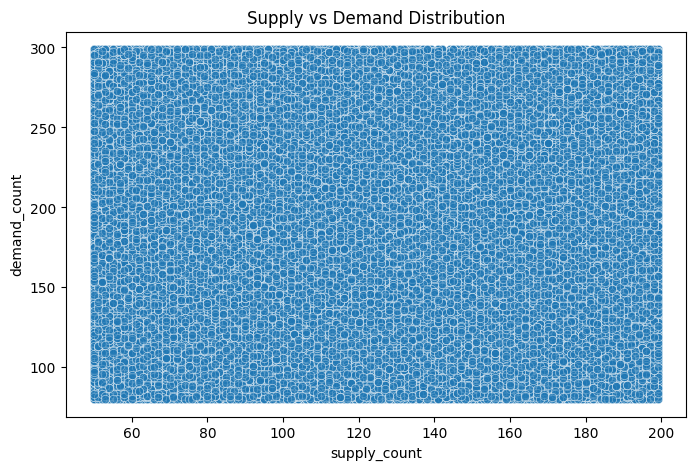

In [14]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="supply_count",
    y="demand_count",
    alpha=0.6
)

plt.title("Supply vs Demand Distribution")
plt.show()

Surge Multiplier Distribution

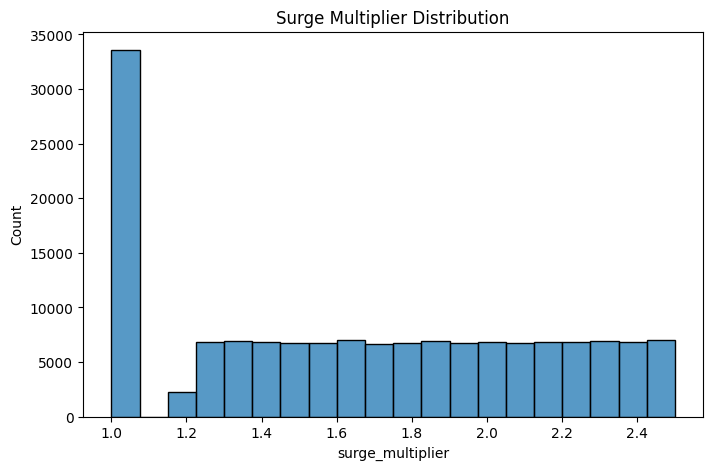

In [15]:
plt.figure(figsize=(8,5))

sns.histplot(df["surge_multiplier"], bins=20)

plt.title("Surge Multiplier Distribution")
plt.show()

Demand Pressure by City

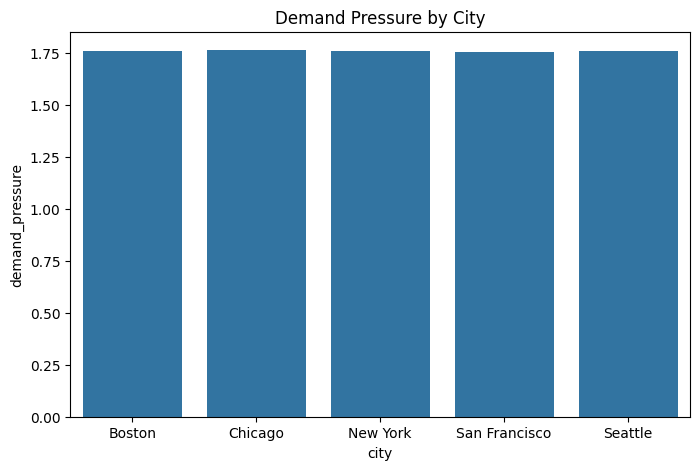

In [16]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=city_summary,
    x="city",
    y="demand_pressure"
)

plt.title("Demand Pressure by City")
plt.show()

Completion Rate Distribution

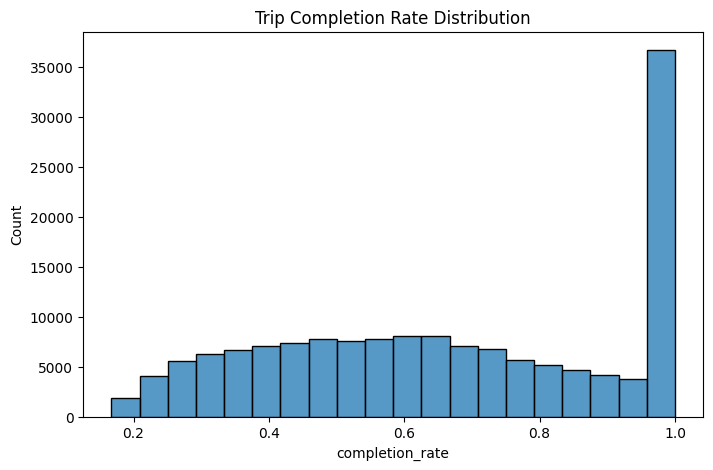

In [17]:
plt.figure(figsize=(8,5))

sns.histplot(df["completion_rate"], bins=20)

plt.title("Trip Completion Rate Distribution")
plt.show()

Save EDA Dataset

In [18]:
df.to_csv("marketplace-supply-demand-analytics/dataset/processed/clean_marketplace_data.csv.csv", index=False)